# Custom Surface Site Analysis
## Identifies unique adsorption sites on any surface using graph isomorphism

Supports: flat slabs (fcc111, fcc332, …), stepped surfaces, surfaces with defects (vacancies), oxide overlayers, and any custom geometry via ACAT `CustomSurface`.

**Edit Cell 2 only, then Run All.**


In [23]:
# Cell 1: import
import sys, os
sys.path.append("/home/shikim/pynta")
from ase import Atom, Atoms
import copy
from ase.io import read, write, Trajectory
from acat.settings import CustomSurface
from acat.adsorption_sites import SlabAdsorptionSites
from ase.build import surface, fcc111
from ase.visualize import view
import importlib
import site_analysis as sa
importlib.reload(sa)


<module 'site_analysis' from '/home/shikim/pynta/pynta/preprocessing/custom_surfaces/defects/site_analysis.py'>

In [ ]:
# Cell 2: inputs  ← edit this cell only, then Run All
xyz_path = "/home/shikim/pynta/pynta/preprocessing/custom_surfaces/defects/fe2o3.xyz"
n_layers = 8
facet = None


In [25]:
#visualize
slab = read(xyz_path)
view(slab, viewer='x3d')

In [26]:
# Cell: Suggest n_layers for CustomSurface
# Run this cell to check what n_layers should be set to in Cell 2.
import importlib
importlib.reload(sa)

from ase.io import read
slab = read(xyz_path)
sa.suggest_n_layers(slab)


Suggested n_layers = 8

   Layer  z mean (Å)  n atoms
  ──────────────────────────────
       1      15.340        4
       2      16.061       16
       3      17.298        8
       4      18.367       12
       5      19.597       12
       6      20.666        8
       7      21.904       16
       8      22.625        4


8

In [ ]:
#workflow keywords

adsorbate_height = 1.0
site_bond_cutoff = 1.5
tag_symbol = "Ne"     # used only if defect is detected
dz = 0.1
stable_steps = 3
verbose = True

# facet: conventional ACAT surface string ("fcc111", "fcc332", "fcc211", ...)
#        Set to None to use CustomSurface (graph-isomorphism, for non-standard surfaces).

In [27]:
# Cell 3: run workflow
# workflow_auto detects defects automatically and picks the right path:
#   - no defect → workflow_no_defect_unique_sites (uses facet string or CustomSurface)
#   - defect    → workflow_defect_vacancy_drop    (always uses CustomSurface)
sa.workflow_auto(
    xyz_path=xyz_path,
    n_layers=n_layers,
    adsorbate_height=adsorbate_height,
    site_bond_cutoff=site_bond_cutoff,
    facet=facet,
    tag_symbol=tag_symbol,
    dz=dz,
    stable_steps=stable_steps,
    verbose=verbose,
)


Found 0 defect site(s)
Sites data saved to 'sites.json'.
Neighbor site list saved to 'neighbor_site_list.json'.
Sites data saved to 'labeled_sites.json'.
Surface             : CustomSurface
Total ACAT sites    : 24
Distinct labels     : 23

  Label        Original site  Morphology
  --------------------------------------------
  ontop0       ontop          terrace
  bridge0      bridge         subsurf
  3fold0       3fold          terrace
  3fold1       3fold          terrace
  3fold2       3fold          terrace
  3fold3       3fold          terrace
  bridge1      bridge         subsurf
  3fold4       3fold          terrace
  3fold5       3fold          terrace
  bridge2      bridge         subsurf
  bridge3      bridge         subsurf
  ontop1       ontop          terrace
  bridge4      bridge         subsurf
  bridge5      bridge         subsurf
  3fold6       3fold          terrace
  3fold7       3fold          terrace
  bridge6      bridge         subsurf
  bridge7      bridge    

([Atoms(symbols='Fe32NeO48', pbc=[True, True, False], cell=[[10.99006386, 0.0, 0.0], [6.247686231748038, 9.041455656945073, 0.0], [0.0, 0.0, 37.96425768740573]], forces=..., tags=...),
  Atoms(symbols='Fe32NeO48', pbc=[True, True, False], cell=[[10.99006386, 0.0, 0.0], [6.247686231748038, 9.041455656945073, 0.0], [0.0, 0.0, 37.96425768740573]], forces=..., tags=...),
  Atoms(symbols='Fe32NeO48', pbc=[True, True, False], cell=[[10.99006386, 0.0, 0.0], [6.247686231748038, 9.041455656945073, 0.0], [0.0, 0.0, 37.96425768740573]], forces=..., tags=...),
  Atoms(symbols='Fe32NeO48', pbc=[True, True, False], cell=[[10.99006386, 0.0, 0.0], [6.247686231748038, 9.041455656945073, 0.0], [0.0, 0.0, 37.96425768740573]], forces=..., tags=...),
  Atoms(symbols='Fe32NeO48', pbc=[True, True, False], cell=[[10.99006386, 0.0, 0.0], [6.247686231748038, 9.041455656945073, 0.0], [0.0, 0.0, 37.96425768740573]], forces=..., tags=...),
  Atoms(symbols='Fe32NeO48', pbc=[True, True, False], cell=[[10.99006386, 0

Sites data saved to 'labeled_sites.json'.


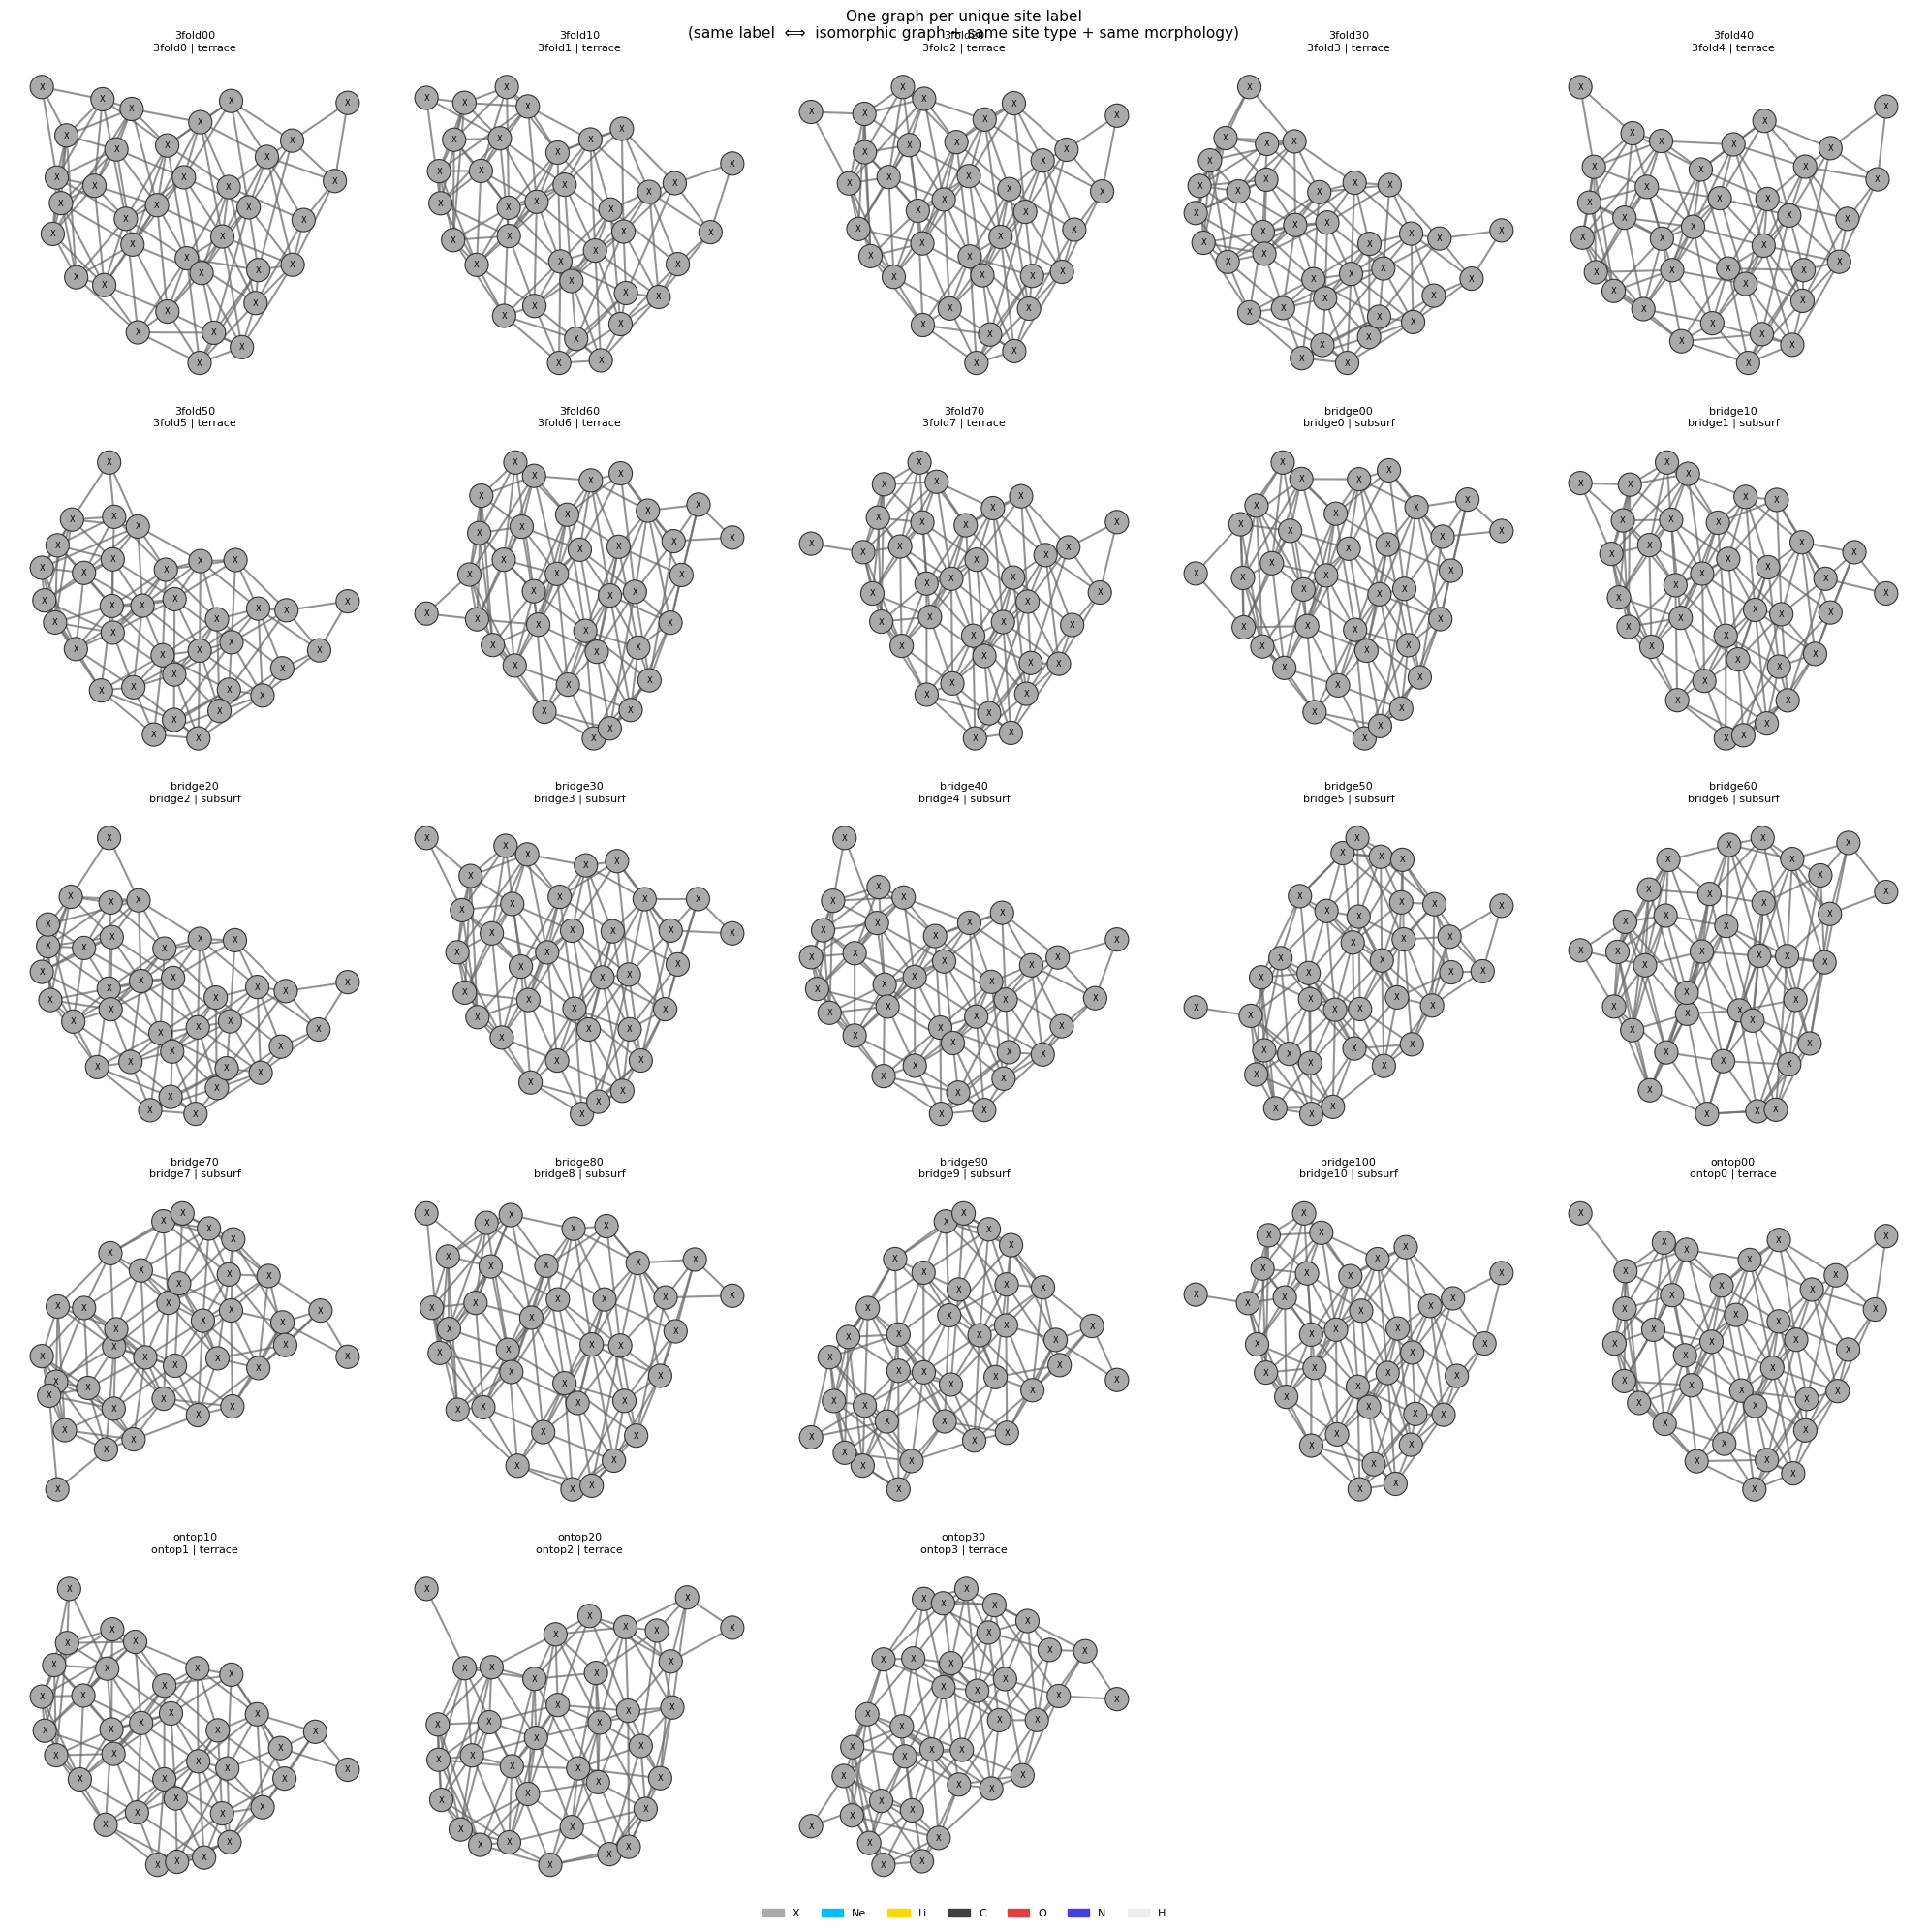

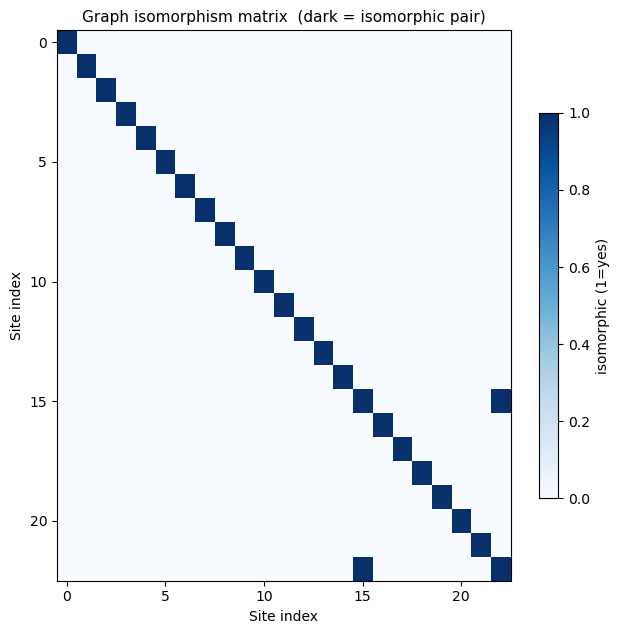

  Total ACAT sites (sites.json)    : 24
  Unique sites     (labeled_sites) : 23

  Each distinct label = one unique site environment.
  'Unique sites' = distinct labels (same thing).

  Label        Original site  Morphology
  ────────────────────────────────────────────
  3fold00      3fold0         terrace
  3fold10      3fold1         terrace
  3fold20      3fold2         terrace
  3fold30      3fold3         terrace
  3fold40      3fold4         terrace
  3fold50      3fold5         terrace
  3fold60      3fold6         terrace
  3fold70      3fold7         terrace
  bridge00     bridge0        subsurf
  bridge10     bridge1        subsurf
  bridge20     bridge2        subsurf
  bridge30     bridge3        subsurf
  bridge40     bridge4        subsurf
  bridge50     bridge5        subsurf
  bridge60     bridge6        subsurf
  bridge70     bridge7        subsurf
  bridge80     bridge8        subsurf
  bridge90     bridge9        subsurf
  bridge100    bridge10       subsurf
  onto

In [28]:
# Cell 4: Graph construction, comparison, and summary
sa.visualize_labeled_sites(
    labeled_sites_json="labeled_sites.json",
    sites_json="sites.json",
)
